In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, make_scorer, accuracy_score
import pandas as pd
import numpy as np
import csv
import pickle 

In [2]:
class TextProcessing:
    def __init__(self, review):
        self.review=review
    def processing(self):
        with open(self.review, 'r', newline='') as f:
            reader = csv.DictReader(f)
            with open('data.csv', 'w', newline='') as out_f:
                fieldnames = ['Country', 'Review Date', 'Review Title', 'Review Text', 'Rating']  
                writer = csv.DictWriter(out_f, fieldnames=fieldnames)
                writer.writeheader()
                for row in reader:
                    writer.writerow({
                        'Country': row['Country'],
                        'Review Date': row['Review Date'],
                        'Review Title': row['Review Title'],
                        'Review Text' : row['Review Text'],
                        'Rating': row['Rating']
                })
        df = pd.read_csv('data.csv', parse_dates=['Review Date'],on_bad_lines='skip')
        df.dropna(inplace=True)
        df.drop_duplicates(inplace=True)
        #df['Rating'].str.split()
        df['Num_Rating']=df['Rating'].apply(lambda x:'POSITIVE' if int(x[6])>=4 else 'NEUTRAL' if int(x[6])==3 else 'NEGATIVE') #if int(x)<3)
        df['Review Date']= df['Review Date'].dt.year
        return df
    def Graph(self):
        df=self.processing()
        fg=df[df['Review Date']>2015]
        df.head()
        df['Num_Rating'].value_counts().plot(kind='bar', color='g')
        df[['Review Date','Num_Rating']] .value_counts()

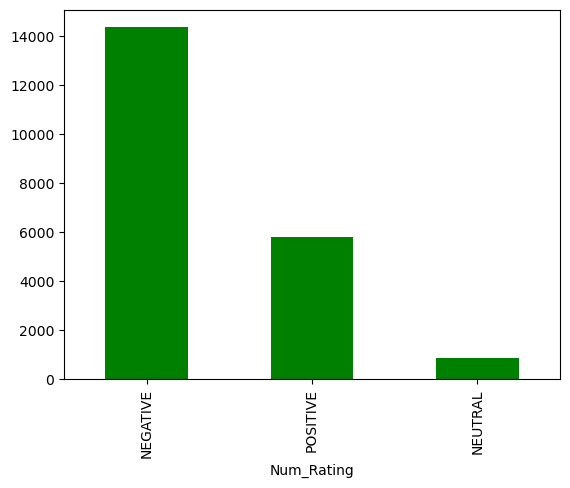

In [3]:
data_ = TextProcessing('Amazon_Reviews.csv')
data_.Graph()

In [4]:
data=data_.processing()
data['num_rate']=data['Num_Rating'].map({'POSITIVE':1.0, 'NEUTRAL':0.0,'NEGATIVE':0.0})
X,y= data['Review Text'].values ,data['num_rate'].values
Xtrain, Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=True)
ytrain[:100].dtype

dtype('float64')

In [7]:
#Model train
pipe=Pipeline([('scalar', TfidfVectorizer()), ('clf', RandomForestClassifier())])

param_grid= [
            {'clf': [KNeighborsClassifier()]},
            {'clf': [SVC()]},
            {'clf': [RandomForestClassifier()]}
            ]
grid= GridSearchCV(estimator=pipe, 
                   param_grid=param_grid,           
                   cv=5,
                   scoring= make_scorer(f1_score, average='macro'),
                   refit = True
                      )
grid.fit(Xtrain, ytrain)

,estimator,Pipeline(step...lassifier())])
,param_grid,"[{'clf': [KNeighborsClassifier()]}, {'clf': [SVC()]}, ...]"
,scoring,make_scorer(f...average=macro)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [8]:
y_pred=grid.predict(Xtest)
score=f1_score(y_pred, ytest)
score

0.845096241979835

In [9]:
y=lambda x: 'Postive Sentiment' if grid.predict(x)==1 else 'Negative Sentiment'

In [ ]:
y(['got value for my money '])

In [ ]:
pipe=[Pipeline([('scaler',TfidfVectorizer()),
      ('model', KNeighborsClassifier())]),
      Pipeline([('scaler', TfidfVectorizer()),
      ('model', SVC())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', RandomForestClassifier())])
      ]
param_grid= [
             {'model__n_neighbors': np.arange(5,20)},
             {'model__class_weight': [{0:1, 1:v} for v in range(10)]},
             {'model__max_depth': np.arange(10)}
            ]

for i in zip(pipe, param_grid):
  mod=GridSearchCV(estimator=i[0], param_grid=i[1], cv=5)
  mod.fit(Xtrain, ytrain)
  print(mod.best_params_)
  print(i[0], i[1])

{'model__n_neighbors': np.int64(13)}
Pipeline(steps=[('scaler', TfidfVectorizer()),
                ('model', KNeighborsClassifier())]) {'model__n_neighbors': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])}


### Model Deployment

In [66]:
with open('model.pkl', 'wb') as f:
    pickle.dump(grid, f)

In [84]:
with open('model.pkl', 'rb') as f:
    model=pickle.load(f)
    y=lambda x: 'Postive Sentiment' if model.predict(x)==1 else 'Negative Sentiment'
    print(y(['not good value for my money']))

Negative Sentiment


In [20]:
voting = VotingClassifier(
    estimators=[
        ('lr', Pipeline([
            ('scaler', CountVectorizer()),
            ('lr', LogisticRegression())
        ])),

        ('svc', Pipeline([
            ('scaler', CountVectorizer()),
            ('svc', SVC())
        ])),

        ('dt', Pipeline([
            ('scaler', CountVectorizer()),
            ('dt', DecisionTreeClassifier())
        ])),

        ('knn', Pipeline([
            ('scaler', CountVectorizer()),
            ('knn', KNeighborsClassifier())
        ]))
    ],
    voting='soft')
#voting.fit(Xtrain, ytrain.ravel())
#y_pred = voting.predict(Xtest)
#print(confusion_matrix(ytest.ravel(), y_pred))
#print(classification_report(ytest.ravel(), y_pred))